<a href="https://colab.research.google.com/github/wingated/cs473/blob/main/mini_labs/week_2_catdist.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BYU CS 473 — Categorical Distribution

### IMPORTANT: The assignment portion is in part 6

---

## Learning Goals
- Understand the concept of categorical distribution  
- Understand how to use One-Hot Encoding to sort categorical data  
- Understand how to use multinomial distribution to model categorical data  



## 1. Introduction to Categorical Distribution

The **categorical distribution** describes the probability of a random variable that can take on one of *k* possible categories, with each having its own probability.

- Example: Rolling a 3-sided die (with outcomes `{A, B, C}`).
- Each category has a probability:  
  $P(X = i) = p_i, \quad \text{where } \sum_{i=1}^k p_i = 1$

We often represent the outcome using **One-Hot encoding**.


## 2. One-Hot Encoding

Categorical data is often encoded numerically for machine learning.  
**One-Hot Encoding** represents each category as a binary vector with a `1` in the position of the chosen category.

Example:  
- Categories: `["A", "B", "C"]`  
- Sample outcome: `"B"`  
- One-Hot: `[0, 1, 0]`


In [36]:
# Example: One-hot encoding with sklearn
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Example categorical samples
samples = ["A", "B", "C", "A", "B", "C", "A"]

# Reshape to column vector for encoder
X = np.array(samples).reshape(-1, 1)

encoder = OneHotEncoder(sparse_output=False)
X_encoded = encoder.fit_transform(X)
X_encoded


array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.]])

## 3. Multinomial Distribution

The **multinomial distribution** extends the categorical distribution to multiple trials.  
- Instead of one outcome, we have `n` trials.  
- The probability of each outcome depends on the categorical probabilities.  

Example: Tossing a 3-sided die 20 times.


In [37]:
# Example: Multinomial distribution with numpy

# Define probability distribution over 3 categories
probs = [0.2, 0.5, 0.3]  # must sum to 1
n_trials = 20
multinomial_sample = np.random.multinomial(n_trials, probs)
multinomial_sample


array([5, 9, 6])

## 4. Visualization of Categorical vs Multinomial Distribution
We can visualize:

1. **Categorical Distribution Simulation** — outcomes from repeated categorical trials.
2. **Multinomial Distribution** — outcome counts over multiple trials.

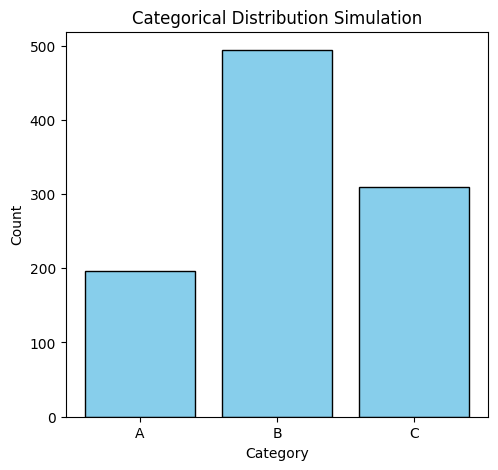

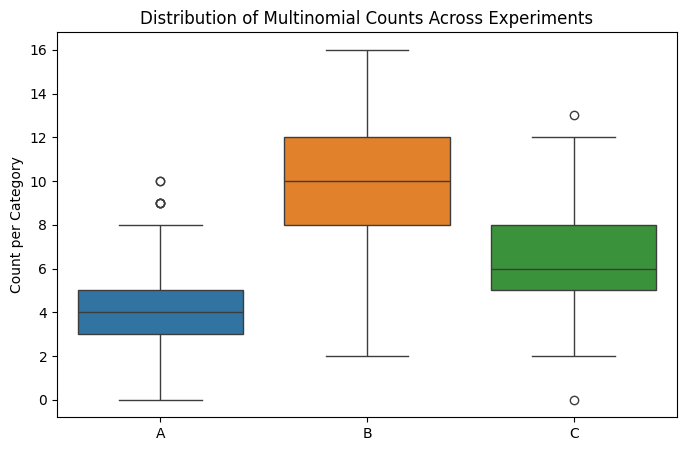

In [38]:
import matplotlib.pyplot as plt

# Define categories and probabilities
categories = ["A", "B", "C"]
probs = [0.2, 0.5, 0.3]

# Parameters
n_trials = 1000
results = np.random.choice(categories, size=n_trials, p=probs)

# Count frequencies (Categorical simulation)
counts = [np.sum(results == c) for c in categories]

# Plot categorical simulation
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(categories, counts, color="skyblue", edgecolor="black")
plt.title("Categorical Distribution Simulation")
plt.xlabel("Category")
plt.ylabel("Count")

import seaborn as sns

# Run many multinomial experiments
n_experiments = 500
n_per_experiment = 20
multi_samples = np.random.multinomial(n_per_experiment, probs, size=n_experiments)

# Convert to DataFrame for plotting
import pandas as pd
df = pd.DataFrame(multi_samples, columns=categories)

# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(data=df)
plt.title("Distribution of Multinomial Counts Across Experiments")
plt.ylabel("Count per Category")
plt.show()



## 5. Summary

- **Categorical Distribution** models a single trial with multiple categories.  
- **One-Hot Encoding** represents categories numerically.  
- **Multinomial Distribution** generalizes the categorical distribution to multiple trials.  

These concepts are fundamental in probability, statistics, and machine learning when handling categorical data.


# 6. Exercises
### Exercise 1
Create a categorical distribution with 4 categories of your choice and assign probabilities.  
- Sample 20 outcomes.  
- Print the frequency of each category.  

In [39]:
# Create categorical distribution with four categories of my choice.
categories = ["Car", "Train", "Bus", "Plane"]

# Assign probabilities.
probs = [0.33, 0.17, 0.10, 0.40]

# Sample 20 outcomes.
n_trials = 20
results = np.random.choice(categories, size=n_trials, p=probs)

# Print the frequency of each category.
counts = [np.sum(results == c) for c in categories]
count_to_freq_conversion = 100 / n_trials

print('Frequencies of each category:')
print(f'Car:  {counts[0] * count_to_freq_conversion}%')
print(f'Train:  {counts[1] * count_to_freq_conversion}%')
print(f'Bus:  {counts[2] * count_to_freq_conversion}%')
print(f'Plane:  {counts[3] * count_to_freq_conversion}%')

Frequencies of each category:
Car:  55.0%
Train:  5.0%
Bus:  5.0%
Plane:  35.0%


### Exercise 2
Using your sampled outcomes from Exercise 1, perform One-Hot Encoding.  
- Show the first 5 encoded vectors.  


In [40]:
# Using sampled outcomes above, perform one-hot encoding.
# Reshape to column vector for encoder.
X = np.array(results).reshape(-1, 1)
encoder = OneHotEncoder(categories=[categories], sparse_output=False)
X_encoded = encoder.fit_transform(X)

# Show the first five encoded vectors.
print(f'First five encoded vectors:')
print(f'{X_encoded[0:5]}')

First five encoded vectors:
[[0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]]


### Exercise 3
Run 100 experiments of 10 trials each using the multinomial distribution.  
- Record the counts.  
- Compare the average counts to the theoretical probabilities.  


In [41]:
# Run 100 experiments of 10 trials each using multinomial distribution.
probs = [0.33, 0.17, 0.10, 0.40]
n_experiments = 100
n_per_experiment = 10
multi_samples = np.random.multinomial(n_per_experiment, probs, size=n_experiments)

# Record the counts.
counts = [0, 0, 0, 0]
for experiment in range(n_experiments):
    counts[0] += multi_samples[experiment][0]
    counts[1] += multi_samples[experiment][1]
    counts[2] += multi_samples[experiment][2]
    counts[3] += multi_samples[experiment][3]

# Compare the average counts to theoretical probabilities.
avg_counts = np.array(counts) / n_experiments
theo_counts = np.array(probs) * n_per_experiment
print(f'Observed Average Counts vs. Theoretical Average Counts:')
print(f'{categories[0]}:  Observed = {avg_counts[0]:.2f}, Theoretical: {theo_counts[0]:.2f},',
      f'Difference (Obs. - Theor.):  {(avg_counts[0] - theo_counts[0]):.2f}')
print(f'{categories[1]}:  Observed = {avg_counts[1]:.2f}, Theoretical: {theo_counts[1]:.2f},',
      f'Difference (Obs. - Theor.):  {(avg_counts[1] - theo_counts[1]):.2f}')
print(f'{categories[2]}:  Observed = {avg_counts[2]:.2f}, Theoretical: {theo_counts[2]:.2f},',
      f'Difference (Obs. - Theor.):  {(avg_counts[2] - theo_counts[2]):.2f}')
print(f'{categories[3]}:  Observed = {avg_counts[3]:.2f}, Theoretical: {theo_counts[3]:.2f},',
      f'Difference (Obs. - Theor.):  {(avg_counts[3] - theo_counts[3]):.2f}')

Observed Average Counts vs. Theoretical Average Counts:
Car:  Observed = 3.45, Theoretical: 3.30, Difference (Obs. - Theor.):  0.15
Train:  Observed = 1.73, Theoretical: 1.70, Difference (Obs. - Theor.):  0.03
Bus:  Observed = 1.00, Theoretical: 1.00, Difference (Obs. - Theor.):  0.00
Plane:  Observed = 3.82, Theoretical: 4.00, Difference (Obs. - Theor.):  -0.18


### Exercise 4
Plot a histogram showing the distribution of counts for one category (e.g., "B") across multiple multinomial experiments.  
- What shape does the histogram resemble?  
- Why do you think that is?  


Text(0, 0.5, 'Number of Experiments')

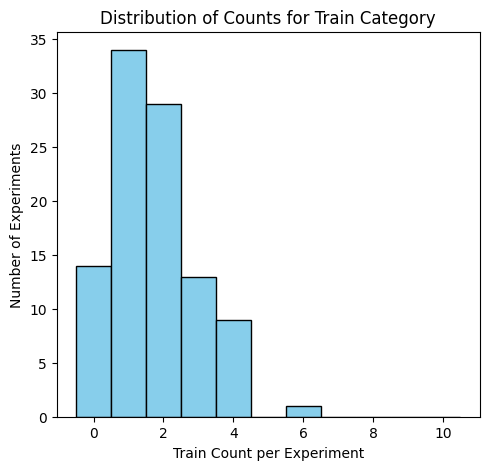

In [42]:
# Record train category counts for each experiment.
train_counts = []
for experiment in range(n_experiments):
    train_counts.append(multi_samples[experiment][1])

# Plot histogram showing distribution of counts.
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(train_counts, bins=np.arange(12) - 0.5, color="skyblue", edgecolor="black")
plt.title("Distribution of Counts for Train Category")
plt.xlabel("Train Count per Experiment")
plt.ylabel("Number of Experiments")

# **EXERCISE 4 RESPONSES**

*Q. What shape does the histogram resemble?*

A. The histogram resembles the shape of a (right-skewed) binomial distribution.


*Q. Why do you think that is?*

A. I believe the histogram resembles a (right-skewed) binomial distribution because it is the marginal distribution of a multinomial distribution.  Considered another way, this is equivalent to a random variable `X ~ Binomial(10, 0.17)` since it is a binary choice (made 10 times per experiment) with a 17% chance of a success (in this case, success means the result of the sample is `train`).  It is right-skewed because the mean (0.17) is much closer to 0 than it is to 1, which means a longer tail can form to the right than it can to the left.

### Exercise 5
Answer in text (2–3 sentences each):

1. How does the categorical distribution differ from the multinomial distribution?  
2. Why is One-Hot encoding important for machine learning models?  
3. If you increased the number of trials in the multinomial distribution, what would happen to the observed frequencies? Why?


# **EXERCISE 5 RESPONSES**

1. The categorical distribution differs from the multinomial distribution in that the multinomial distribution considers multiple trials.  In essence, a multinomial distribution records the counts of repeated categorical trials.

2. One-hot encoding is important for machine learning models because it allows categorical data to be represented numerically with a common scoring metric, even though categories are typically non-numeric by nature.  Machine learning algorithms often require numeric inputs, so this allows us to apply these machine learning algorithms to categorical (non-numeric) data.  Additionally, one-hot encoding represents categories (such as ZIP codes) without falsely implying any ordinal relationships between the categories.

3. If one were to increase the number of trials in the multinomial distribution, their observed relative frequencies would closely resemble the categorical probabilities.  This is because, due to the Law of Large Numbers, the observed frequencies converge to the theoretical frequencies for each category as the number of trials increases.